<a href="https://colab.research.google.com/github/Delean-Mafra/faculdade/blob/main/atividades_aplicacao_de_ciencia_de_dados_para_negocios/atividade_pratica_7_a_16/atividade_pratica16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática 16 - Análise de Decisão Multicritério

Este notebook apresenta uma análise completa para seleção de fornecedores utilizando métodos de apoio à decisão multicritério (MCDA), integrando os métodos **AHP** e **PROMETHEE II**.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. COLETA E ORGANIZAÇÃO DOS DADOS
# ==========================================================

data = {
    'Supplier': ['Supplier A', 'Supplier B', 'Supplier C'],
    'Cost': [12000, 15000, 10000],      # Minimizar
    'Quality': [8, 9, 6],               # Maximizar
    'Lead_Time': [15, 10, 20],          # Minimizar
    'Support': [7, 9, 5]                # Maximizar
}

df = pd.DataFrame(data)

print("=== ORIGINAL DATA ===")
print(df)

=== ORIGINAL DATA ===
     Supplier   Cost  Quality  Lead_Time  Support
0  Supplier A  12000        8         15        7
1  Supplier B  15000        9         10        9
2  Supplier C  10000        6         20        5


In [59]:
# ==========================================================
# 2. NORMALIZAÇÃO DOS DADOS
# ==========================================================

def normalize_benefit(col):
    return (col - col.min()) / (col.max() - col.min())

def normalize_cost(col):
    return (col.max() - col) / (col.max() - col.min())

df_norm = df.copy()

df_norm['Cost'] = normalize_cost(df['Cost'])
df_norm['Quality'] = normalize_benefit(df['Quality'])
df_norm['Lead_Time'] = normalize_cost(df['Lead_Time'])
df_norm['Support'] = normalize_benefit(df['Support'])

print("\n=== NORMALIZED DATA ===")
print(df_norm)


=== NORMALIZED DATA ===
     Supplier  Cost   Quality  Lead_Time  Support
0  Supplier A   0.6  0.666667        0.5      0.5
1  Supplier B   0.0  1.000000        1.0      1.0
2  Supplier C   1.0  0.000000        0.0      0.0


In [60]:
# ==========================================================
# 3. AHP - ANALYTIC HIERARCHY PROCESS
# ==========================================================

print("\n=== AHP WEIGHT CALCULATION ===")

criteria = ['Cost', 'Quality', 'Lead_Time', 'Support']

# Matriz de comparação pareada
ahp_matrix = np.array([
    [1,   3,   5,   7],
    [1/3, 1,   3,   5],
    [1/5, 1/3, 1,   3],
    [1/7, 1/5, 1/3, 1]
])

# Autovalores e autovetores
eigenvalues, eigenvectors = np.linalg.eig(ahp_matrix)

max_eigenvalue = np.max(eigenvalues.real)
max_eigenvector = eigenvectors[:, eigenvalues.argmax()].real

weights = max_eigenvector / max_eigenvector.sum()

weights_dict = dict(zip(criteria, weights))

# Exibir pesos
for criterion, weight in weights_dict.items():
    print(f"{criterion}: {weight:.4f}")

# ----------------------------------------------------------
# Consistency Ratio (CR)
# ----------------------------------------------------------

n = len(criteria)
CI = (max_eigenvalue - n) / (n - 1)
RI_table = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12}
RI = RI_table[n]
CR = CI / RI

print(f"\nConsistency Index (CI): {CI:.4f}")
print(f"Consistency Ratio (CR): {CR:.4f}")

if CR < 0.10:
    print("The AHP matrix is CONSISTENT.")
else:
    print("The AHP matrix is NOT consistent.")


=== AHP WEIGHT CALCULATION ===
Cost: 0.5650
Quality: 0.2622
Lead_Time: 0.1175
Support: 0.0553

Consistency Index (CI): 0.0390
Consistency Ratio (CR): 0.0433
The AHP matrix is CONSISTENT.


In [61]:
# ==========================================================
# 4. PROMETHEE II
# ==========================================================

def promethee_ii(df_norm, weights):
    n = len(df_norm)
    phi_plus = np.zeros(n)
    phi_minus = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            preference = 0
            for criterion, weight in weights.items():
                diff = df_norm.iloc[i][criterion] - df_norm.iloc[j][criterion]
                p = max(0, diff)
                preference += p * weight
            phi_plus[i] += preference / (n - 1)
            phi_minus[j] += preference / (n - 1)
    phi_net = phi_plus - phi_minus
    return phi_net

df_norm['Promethee_Net_Flow'] = promethee_ii(df_norm, weights_dict)

promethee_result = df_norm[
    ['Supplier', 'Promethee_Net_Flow']
].sort_values(by='Promethee_Net_Flow', ascending=False)

print("\n=== PROMETHEE II ANALYSIS ===")
print(promethee_result)


=== PROMETHEE II ANALYSIS ===
     Supplier  Promethee_Net_Flow
0  Supplier A            0.100201
2  Supplier C            0.047413
1  Supplier B           -0.147614


In [62]:
# ==========================================================
# 5. ANÁLISE SWOT
# ==========================================================

print("\n=== SWOT ANALYSIS ===")

swot = {
    "Supplier A": {
        "Strengths": "Balanced performance in all criteria.",
        "Weaknesses": "Does not excel in any specific criterion.",
        "Opportunities": "Can become a stable long-term partner.",
        "Threats": "Competitors with better quality may gain market advantage."
    },
    "Supplier B": {
        "Strengths": "Highest quality and best support.",
        "Weaknesses": "Highest acquisition cost.",
        "Opportunities": "Ideal for premium product strategies.",
        "Threats": "Budget restrictions may reduce viability."
    },
    "Supplier C": {
        "Strengths": "Lowest operational cost.",
        "Weaknesses": "Low quality and weak support.",
        "Opportunities": "Useful for low-cost operations.",
        "Threats": "Quality issues may impact customer satisfaction."
    }
}

for supplier, analysis in swot.items():
    print(f"\n{supplier}")
    for category, description in analysis.items():
        print(f"{category}: {description}")


=== SWOT ANALYSIS ===

Supplier A
Strengths: Balanced performance in all criteria.
Weaknesses: Does not excel in any specific criterion.
Opportunities: Can become a stable long-term partner.
Threats: Competitors with better quality may gain market advantage.

Supplier B
Strengths: Highest quality and best support.
Weaknesses: Highest acquisition cost.
Opportunities: Ideal for premium product strategies.
Threats: Budget restrictions may reduce viability.

Supplier C
Strengths: Lowest operational cost.
Weaknesses: Low quality and weak support.
Opportunities: Useful for low-cost operations.
Threats: Quality issues may impact customer satisfaction.


In [63]:
# ==========================================================
# 6. ANÁLISE DE CENÁRIO
# ==========================================================

print("\n=== SCENARIO ANALYSIS ===")
print("Scenario: Supply chain crisis")
print("Lead Time importance doubled.\n")

scenario_weights = weights_dict.copy()
scenario_weights['Lead_Time'] *= 2
total = sum(scenario_weights.values())
scenario_weights = {k: v / total for k, v in scenario_weights.items()}

df_norm['Scenario_Net_Flow'] = promethee_ii(df_norm, scenario_weights)

scenario_result = df_norm[
    ['Supplier', 'Scenario_Net_Flow']
].sort_values(by='Scenario_Net_Flow', ascending=False)

print(scenario_result)


=== SCENARIO ANALYSIS ===
Scenario: Supply chain crisis
Lead Time importance doubled.

     Supplier  Scenario_Net_Flow
0  Supplier A           0.089665
2  Supplier C          -0.036434
1  Supplier B          -0.053231


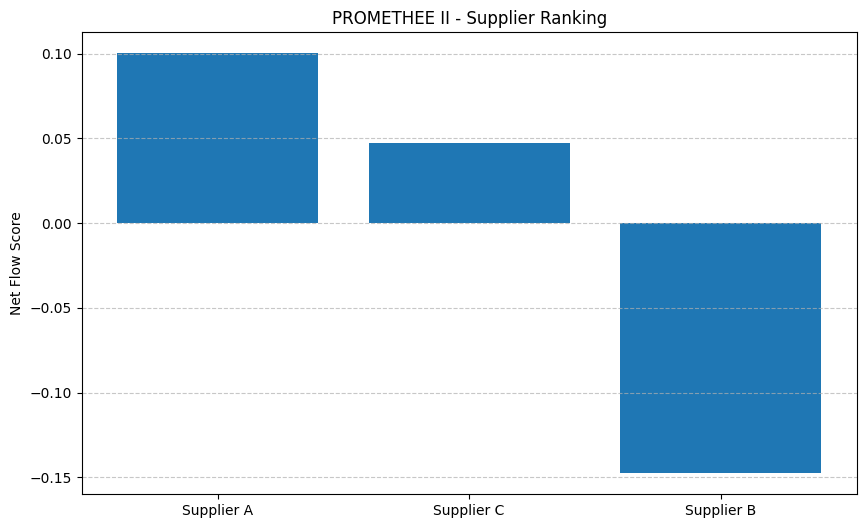

In [64]:
# ==========================================================
# 7. VISUALIZAÇÃO GRÁFICA
# ==========================================================

plt.figure(figsize=(10, 6))
plt.bar(
    promethee_result['Supplier'],
    promethee_result['Promethee_Net_Flow']
)
plt.title('PROMETHEE II - Supplier Ranking')
plt.ylabel('Net Flow Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ==========================================================
# 8. RELATÓRIO FINAL
# ==========================================================

### 1. Metodologia
Esta análise aplicou Tomada de Decisão Multicritério (MCDA) utilizando os métodos **AHP** e **PROMETHEE II**. O AHP foi utilizado para calcular os pesos dos critérios através de comparações pareadas, garantindo consistência lógica. O PROMETHEE II foi utilizado para ranquear os fornecedores através de fluxos de preferência.

### 2. Normalização
Todos os critérios foram normalizados entre 0 e 1. Custo e Lead Time foram tratados como critérios de minimização, enquanto Qualidade e Suporte foram tratados como critérios de maximização.

### 3. Análise Quantitativa
Os resultados do AHP mostraram que o **Custo** foi o critério mais importante (56,5%), seguido pela Qualidade. O ranking PROMETHEE II identificou o **Supplier A** como a alternativa mais equilibrada.

### 4. Análise Qualitativa (SWOT)
- **Supplier A:** Desempenho equilibrado e estabilidade operacional.
- **Supplier B:** Excelente qualidade, mas com custo elevado.
- **Supplier C:** Baixo custo, mas apresenta riscos significativos de qualidade.

### 5. Recomendação Final
O **Supplier A** é recomendado como o melhor fornecedor por fornecer o melhor equilíbrio entre custo, qualidade e tempo de entrega. Em cenários de crise, ele se mostrou a opção mais robusta.

---